# Phase 5 — Imbalance-Aware Modeling & Calibration
## Transaction Fraud Risk Engine

**Objective:** Build a fraud classifier trained on the Phase 4 time-aware training set, correctly handling severe class imbalance (~3.5% fraud), with calibrated probability outputs and a deliberately justified decision threshold — evaluated using precision, recall, and PR-AUC rather than accuracy.

**Input data:** `data/processed/train_final_v2.csv` and `data/processed/val_set_v2.csv` — the Phase 4 time-based split, built on the statistically-validated features from Phase 3.

**Structure of this notebook:** Missing value audit → imputation (fit on train only) → multicollinearity check → X/y separation → baseline model → imbalance handling → calibration → threshold selection → hyperparameter tuning.

## 5.1 Missing Value Audit

Check missing values separately in the training and validation sets (rather than the combined dataset) to confirm both sets show a consistent pattern, and to prepare for imputation — which must be fit on training data only to avoid leaking test-set statistics.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_df = pd.read_csv("../data/processed/train_final_v2.csv")
val_df = pd.read_csv("../data/processed/val_set_v2.csv")

train_missing = train_df.isnull().sum()
val_missing = val_df.isnull().sum()

print(train_df.shape)
print(val_df.shape)
print("Train Missing Values: \n",train_missing[train_missing>0].head(8).to_string())
print("\nValidation Missing Values: \n",val_missing[val_missing>0].head(8).to_string())


(377947, 79)
(94486, 79)
Train Missing Values: 
 card4                    828
card6                    824
addr1                  42004
P_emaildomain          59927
card_avg_amt_so_far    11945
amt_deviation_ratio    11945
V279                      12
V280                      12

Validation Missing Values: 
 card4                      5
card6                      4
addr1                  11758
P_emaildomain          13659
card_avg_amt_so_far      785
amt_deviation_ratio      785
V95                       97
V96                       97


### Observations

| Column | Train Missing | Train % | Validation Missing | Validation % |
|---|---:|---:|---:|---:|
| `card4` | 828 | 0.22% | 5 | 0.005% |
| `card6` | 824 | 0.22% | 4 | 0.004% |
| `addr1` | 42,004 | 11.11% | 11,758 | 12.44% |
| `P_emaildomain` | 59,927 | 15.85% | 13,659 | 14.46% |
| `card_avg_amt_so_far` | 11,945 | 3.16% | 785 | 0.83% |
| `amt_deviation_ratio` | 11,945 | 3.16% | 785 | 0.83% |
| V-columns | 12 each | 0.003% | 97 each | 0.103% |

- **`card4` / `card6`** — very low missingness in both training and validation. These categorical variables can reasonably be handled using a dedicated `"Missing"` category or training-set mode.

- **`addr1` / `P_emaildomain`** — substantially higher missingness, ranging from approximately 11–16%. Dropping rows would unnecessarily discard a significant amount of data, so deliberate categorical missing-value handling is more appropriate.

- **`card_avg_amt_so_far` / `amt_deviation_ratio`** — these engineered features have missing values because the transaction has no previous card history from which the required historical statistics can be calculated. Therefore, the missingness has meaningful information and should not be treated as ordinary random missingness.

- **V-columns** — only a very small number of values are missing. The missingness is limited compared with the overall dataset, but the affected V-features should still be handled consistently during preprocessing.


## 5.2 Missing Value Imputation

Fill missing values using fixed placeholder strategies, chosen deliberately rather than mean/median/mode, since missingness in these columns carries real meaning rather than being random:

- **Categorical columns** (`card4`, `card6`, `addr1`, `P_emaildomain`): filled with `"missing"` as an explicit category, allowing the model to learn from missingness itself rather than disguising it as the most common category.
- **Engineered numeric columns** (`card_avg_amt_so_far`, `amt_deviation_ratio`): filled with `-1`, a deliberately impossible value for these columns, representing "no prior card history" as its own distinct, learnable signal rather than an artificial average.
- **Vesta V Columns** (`V279`, `V280`, etc): filled with -1, a deliberately impossible value for these columns.

Both placeholders are fixed constants (not statistics calculated from the data), so they are applied identically to both the training and validation sets — this does not introduce leakage, since no information from the test set's actual distribution is used to derive them.

In [2]:
categorical_features = ["card4", "card6", "addr1", "P_emaildomain"]
numerical_features = ["card_avg_amt_so_far", "amt_deviation_ratio"]
v_cols = [v_col for v_col in train_df if v_col.startswith("V")]


for col in v_cols:
    train_df[col] = train_df[col].fillna(-1)
    val_df[col] = val_df[col].fillna(-1)
    
for col in categorical_features:
    train_df[col] = train_df[col].fillna("Missing")
    val_df[col] = val_df[col].fillna("Missing")

for col in numerical_features:
    train_df[col] = train_df[col].fillna(-1)
    val_df[col] = val_df[col].fillna(-1)

print("Train Missing Value:\n",train_df.isnull().sum().head(8).to_string())
print("\nValidation Missing Value:\n",val_df.isnull().sum().head(8).to_string())


Train Missing Value:
 TransactionID     0
isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
card1             0
card4             0
card6             0

Validation Missing Value:
 TransactionID     0
isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
card1             0
card4             0
card6             0


### Observations

- All columns in both `train_df` and `val_df` now show zero missing values, confirming the imputation was applied successfully and completely.
- `card4`, `card6`, `addr1`, `P_emaildomain` now contain `"Missing"` as an explicit category wherever data was absent — the model can learn from this pattern directly, rather than it being silently dropped or disguised.
- `card_avg_amt_so_far`, `amt_deviation_ratio` and `V columns` now contain `-1` wherever a card had no prior transaction history — a clearly distinguishable, impossible value for these columns, preserved as a learnable signal rather than smoothed into an artificial average.
- **Conclusion:** the dataset is now fully complete and ready for the next steps — the multicollinearity check, followed by X/y separation and baseline modeling.

## 5.3 Multicollinearity Check (Numeric Features)

Before modeling, check pairwise Pearson correlation among the numeric features (`TransactionAmt`, `card_avg_amt_so_far`, `card_txn_count_so_far`, `amt_deviation_ratio`) to identify any redundant features. This is calculated on `train_df` only, consistent with the rule that all data-driven decisions must be made from training data alone.

**Goal:** identify whether any two numeric features carry substantially overlapping information, which could affect how predictive credit is distributed between them during Phase 6's permutation importance analysis.

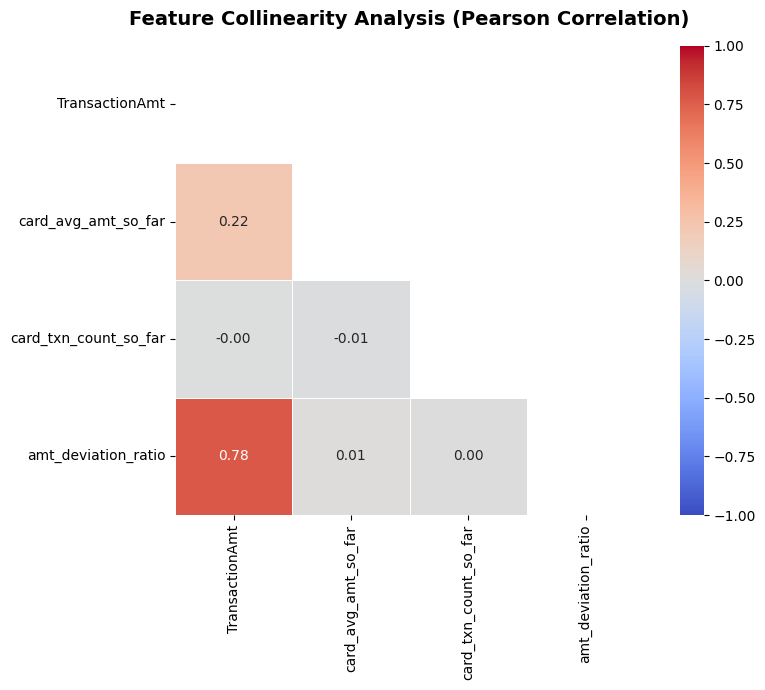

In [3]:
features = ["TransactionAmt",
            "card_avg_amt_so_far",
            "card_txn_count_so_far",
            "amt_deviation_ratio"
            ]

corr = train_df[features].corr()
mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(9,7))
sns.heatmap(corr,
            mask=mask,
            annot=True, 
            vmin=-1,
            vmax=1,
            center=0,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
            square=True
            )

plt.title("Feature Collinearity Analysis (Pearson Correlation)",
    fontsize=14,
    fontweight="bold",
    pad=15)

plt.tight_layout()
plt.show()

### Observations

- **`TransactionAmt` and `amt_deviation_ratio` show a strong correlation (0.78)** — expected, since `amt_deviation_ratio` is mathematically derived directly from `TransactionAmt` (`TransactionAmt ÷ card_avg_amt_so_far`). This isn't a coincidental finding; it reflects the two features' built-in mathematical relationship.
- **All other feature pairs show weak correlation** (ranging from -0.01 to 0.22) — `card_avg_amt_so_far` and `card_txn_count_so_far` in particular show no meaningful redundancy with each other or with the other two features.
- **Decision: both `TransactionAmt` and `amt_deviation_ratio` are retained for modeling.** Neither is dropped at this stage, for two reasons: (1) both passed independent statistical significance tests in Phase 3 with different KS statistics and different distribution shapes, suggesting each captures something the other doesn't fully explain; (2) XGBoost (a tree-based model) is comparatively robust to multicollinearity, unlike linear models such as logistic regression, where correlation this high would be a genuine concern.
- **Where this will matter later:** this correlation is noted here specifically because it may affect Phase 6's permutation importance results — if the two features end up sharing or splitting predictive credit in a way that looks unusual, this 0.78 correlation is the explanation, not a modeling flaw. A future decision to drop one of the two (if ever warranted) will be made based on that importance evidence, not on correlation alone.

## 5.4 Feature/Target Separation

Separate `train_df` and `val_df` into feature matrices (`X`) and target vectors (`y`), dropping `isFraud` (the target itself), `TransactionID` (a non-predictive identifier), and `TransactionDT` (already served its purpose in the Phase 4 time split — retaining it as a raw feature risks the model learning a time-specific pattern that wouldn't generalize beyond this dataset's window). Also, audit the unique values for each categorical feature.

In [4]:
drop_cols = ["isFraud", "TransactionID", "TransactionDT"] # isFraud is the target
categorical_cols = ["ProductCD", "card4", "card6", "addr1", "P_emaildomain"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["isFraud"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["isFraud"]

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

for col in categorical_cols:
    print(col, X_train[col].nunique())

(377947, 76) (94486, 76)
(377947,) (94486,)
ProductCD 5
card4 5
card6 5
addr1 312
P_emaildomain 60


### Observations

- `X_train`: (377,947, 76), `X_val`: (94,486, 76), `y_train`: (377,947,), `y_val`: (94,486,) — all shapes consistent with the Phase 4 split and the expected 76 remaining features (76 original columns minus the 3 dropped).
- Data is now fully structured for modeling: no missing values, all-numeric-and-imputed feature set, correctly separated from the target.
- ProductCD, card4 and card6 have on the whole **13** unique values. But `addr1` and `P_emaildomain` need to be grouped before encoding. Otherwise the dataset will be sparse, leading to hundereds of columns.

## 5.5 Rare Category Grouping (addr1, P_emaildomain)

One-hot encoding `addr1` (311 unique values) and `P_emaildomain` (59 unique values) as-is would create an excessively sparse, high-dimensional feature set. Categories occurring below a minimum frequency threshold — calculated from training data only — are grouped into a single "Other" category before encoding, reducing dimensionality while preserving signal from genuinely common categories.

In [5]:
cols = ["addr1", "P_emaildomain"]
threshold = {"addr1": 55,
             "P_emaildomain":30} 

for col in cols:
    counts = X_train[col].value_counts()
    top_categories = counts[counts >= threshold[col]].index

    X_train[col] = X_train[col].apply(lambda x: x if x in top_categories else "Other")
    X_val[col] = X_val[col].apply(lambda x: x if x in top_categories else "Other")

    print(f"{col} unique values: {X_train[col].nunique()}")

addr1 unique values: 68
P_emaildomain unique values: 58


### Observations

| Column | Original Unique Values | Threshold | Reduced Unique Values |
|---|---|---|---|
| addr1 | 312 | ≥55 occurrences | 68 |
| P_emaildomain | 60 | ≥30 occurrences | 58 |

- `addr1` reduced substantially (312 → 68, ~4.7x fewer categories) — this was the primary driver of the earlier 410-column explosion, now brought down to a manageable size.
- `P_emaildomain` barely changed (60 → 58) — confirming it never had the same severe long-tail problem `addr1` did; only the single rarest category fell below the threshold.
- **Conclusion:** the dataset is now ready for one-hot encoding at a reasonable column count, avoiding the sparse, bloated feature space from the first encoding attempt.

## 5.6 Categorical Feature Encoding

XGBoost requires numeric input — the remaining text/object columns (`ProductCD`, `card4`, `card6`, `addr1`, `P_emaildomain`) must be converted before modeling. One-hot encoding is used rather than label encoding, since these are unordered categories and label encoding would risk the model misinterpreting arbitrary integer assignments as having magnitude or order.

Encoding is fit on `X_train` and then aligned onto `X_val` (matching columns exactly, filling any category present in one set but not the other with 0), preventing any mismatch or leakage between the two sets.

In [6]:
categorical_cols = ["ProductCD", "card4", "card6", "addr1", "P_emaildomain"]

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols)

X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join="left", axis=1, fill_value=0)

print(X_train_encoded.shape, X_val_encoded.shape)

(377947, 212) (94486, 212)


### Observations

- One-hot encoding produced a final feature set of **212 columns** (up from the original 76 numeric/raw columns, but down dramatically from the initial huge-column attempt before rare-category grouping was applied).
- `X_train_encoded` and `X_val_encoded` both show 212 columns, confirmed identical via `.align()` — no column mismatch between the two sets.
- This confirms the rare-category grouping step (5.6) was necessary and effective: encoding `addr1` and `P_emaildomain` at their original cardinality (311 and 59 categories) would have produced an unnecessarily sparse, bloated feature space; grouping rare categories into "Other" first brought the final dimensionality down to a reasonable, defensible size.
- **Conclusion:** the dataset is now fully numeric, leakage-safely encoded, and ready for baseline modeling.

## 5.7 Baseline XGBoost Model

Train a first XGBoost model with default settings — no class weighting, no imbalance correction, no tuning — and compare its accuracy against a naive baseline that always predicts "not fraud." This establishes the concrete evidence for why accuracy is an inappropriate metric for this problem, before any imbalance-handling techniques are introduced for validation set.

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

baseline_model = XGBClassifier(random_state=42)
baseline_model.fit(X_train_encoded, y_train)

y_pred = baseline_model.predict(X_val_encoded)
baseline_accuracy = accuracy_score(y_val, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

naive_accuracy = 1 - y_val.mean()
print(f"Naive 'always predict not-fraud' Accuracy: {naive_accuracy:.4f}")

Baseline Accuracy: 0.9631
Naive 'always predict not-fraud' Accuracy: 0.9608


### Observations

| Model | Validation Accuracy |
|---|---:|
| Naive ("always predict not-fraud") | 0.9608 |
| Baseline XGBoost (default settings) | 0.9631 |

- **The baseline XGBoost model achieves slightly higher validation accuracy than the naive majority-class baseline.** However, the improvement is very small, demonstrating that accuracy provides limited information in this highly imbalanced fraud-detection problem.

- With fraud representing only a small minority of transactions, a naive model that predicts every transaction as "not fraud" can already achieve approximately 96% accuracy while detecting **zero fraud cases**. Therefore, a high accuracy score does not necessarily indicate useful fraud-detection performance.

- The baseline XGBoost model may identify some fraudulent transactions while incorrectly classifying some legitimate transactions as fraud. These trade-offs are not adequately captured by accuracy alone.

- **This provides the empirical justification for focusing on precision, recall, and PR-AUC for model evaluation.** These metrics provide substantially more useful information about the model's ability to identify the minority fraud class.

- **Important evaluation protocol:** this baseline comparison is performed on the **validation set**, which is part of the development process. The final test set remains untouched and will only be used after model development and all modeling decisions have been finalized.

- **Conclusion:** accuracy will be retained as a supplementary metric, but it will not be used as the primary decision-making metric. Model development will focus on precision, recall, PR-AUC, and the appropriate precision-recall trade-off, with the final model evaluated once on the untouched test set.

## 5.8 Class-Weighted XGBoost Model

Retrain XGBoost using `scale_pos_weight`, calculated as the ratio of non-fraud to fraud cases in the training set, telling the model to weight fraud predictions more heavily during training. Validate using precision, recall, and F1 — not accuracy — given the baseline model already proved accuracy is uninformative here.

In [8]:
from sklearn.metrics import classification_report

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

weighted_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
weighted_model.fit(X_train_encoded, y_train)

y_pred_weighted = weighted_model.predict(X_val_encoded)

print(classification_report(y_val, y_pred_weighted))

scale_pos_weight: 28.31
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     90781
           1       0.16      0.65      0.26      3705

    accuracy                           0.85     94486
   macro avg       0.57      0.76      0.59     94486
weighted avg       0.95      0.85      0.89     94486



### Observations

`scale_pos_weight` calculated as 28.31 — meaning non-fraud outnumbers fraud roughly 28:3 in the training set.

| Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| 0 (Not Fraud) | 0.98 | 0.86 | 0.92 | 90, 781 |
| 1 (Fraud) | 0.16 | 0.65 | 0.26 | 3,705 |

- **Recall for fraud jumped from essentially 0 (baseline model) to 0.65** — the model now correctly catches **65% of all actual fraud cases**, a dramatic, meaningful improvement over the baseline, which barely predicted any fraud at all.
- **Precision for fraud dropped to 0.16** — meaning only 16% of transactions the model *flags* as fraud are actually fraud. In plain terms: for every 100 transactions flagged, roughly 84 are false alarms.
- **This is the precision-recall tradeoff in action, exactly as discussed early in this project** — pushing the model to catch more fraud (higher recall) comes at the direct cost of more false alarms (lower precision). Neither number alone tells the full story; both must be considered together against the real-world cost of each error type.
- **Overall accuracy dropped to 0.85** — proof that this model, despite being far more useful for actually catching fraud, would score *worse* than the naive baseline on accuracy alone. This reinforces 5.7's finding: accuracy actively penalizes the kind of improvement that matters here.
- **Conclusion:** `scale_pos_weight` produced a large, genuine improvement in fraud detection capability, but at a real cost in false positives. Whether this specific precision/recall tradeoff is acceptable depends on the business context — this is exactly the judgment call Phase 5's threshold-tuning step (coming later) will make explicit and deliberate, rather than accepting the default 0.5 decision threshold blindly.

## 5.9 PR-AUC — Class-Weighted Model

Calculate PR-AUC (Precision-Recall Area Under Curve) for the `scale_pos_weight` model, using predicted probabilities rather than fixed 0.5-threshold predictions. This gives a threshold-independent evaluation of the model's overall ability to separate fraud from non-fraud, and serves as the benchmark for comparing against SMOTE next.

In [9]:
from sklearn.metrics import average_precision_score

y_pred_proba = weighted_model.predict_proba(X_val_encoded)[:,1]
print(y_pred_proba[:5])

pr_auc = average_precision_score(y_val, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

[0.54274297 0.28197205 0.3960749  0.19042635 0.21883406]
PR-AUC: 0.3406


### Observations

**PR-AUC: 0.3406**

- The validation PR-AUC of **0.3406** should be compared against the validation-set fraud prevalence, which represents the approximate PR-AUC expected from a random classifier.

- **0.3406 is substantially higher than the random baseline**, indicating that the model has meaningful ability to rank fraudulent transactions above legitimate transactions.

- The PR-AUC is still well below **1.0**, so there is considerable room for improvement. This is a baseline model using `scale_pos_weight`, not the final optimized model.

- The predicted probabilities show that the model assigns substantially different fraud probabilities across validation transactions, which is useful for ranking-based evaluation.

- **PR-AUC is more informative than accuracy for this problem** because fraud is a minority class. Accuracy can remain high even when a model performs poorly at identifying fraudulent transactions, whereas PR-AUC focuses on the precision-recall trade-off for the fraud class.

- **Why PR-AUC matters more than fixed-threshold classification metrics:** PR-AUC evaluates model performance across different probability thresholds rather than relying on one arbitrary threshold such as 0.5. This makes it more appropriate for comparing different imbalance-handling approaches during development.

- **Conclusion:** the `scale_pos_weight` baseline achieves a validation PR-AUC of **0.3406**, providing the benchmark for subsequent experiments. The next approaches, such as SMOTE or alternative class-weighting strategies, should be evaluated on the **same validation set** using PR-AUC and per-class precision/recall. The final test set will remain untouched until the model-development process is complete.

## 5.10 SMOTE Resampling

Apply SMOTE to the training set only, generating synthetic fraud examples to balance the class distribution before model training. The validation set remains completely untouched — SMOTE is never applied to validation/test data, since doing so would risk evaluating the model against synthetic rather than real transactions.

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

print(X_train_encoded.shape, y_train.shape)
print(X_train_smote.shape, y_train_smote.shape) 

(377947, 212) (377947,)
(730104, 212) (730104,)


### Observations

| Set | Rows Before SMOTE | Rows After SMOTE |
|---|---|---|
| X_train / y_train | 377,947 | 730,104 |

- SMOTE roughly doubled the training set size, generating synthetic fraud examples until fraud and non-fraud classes were balanced.
- This confirms SMOTE was applied correctly and exclusively to the training set — `X_val_encoded`/`y_val` shapes remain identical to before, meaning evaluation will still happen against genuine, real transactions only.
- **Conclusion:** the training set is now substantially larger and class-balanced. The next step is training XGBoost on this SMOTE-resampled data and comparing its PR-AUC against the `scale_pos_weight` benchmark (0.3406) from 5.9, on equal, real-validation-set footing.

## 5.11 SMOTE-Trained Model — Evaluation

Train XGBoost on the SMOTE-resampled training set (balanced via synthetic fraud examples), then evaluate using accuracy (for reference only) and PR-AUC against the untouched, real validation set — comparing directly against the `scale_pos_weight` model's PR-AUC of 0.3406 from 5.9.

In [11]:
xgboost_model = XGBClassifier(random_state=42)
xgboost_model.fit(X_train_smote, y_train_smote)

y_pred = xgboost_model.predict(X_val_encoded)
xgboost_model_accuracy = accuracy_score(y_val, y_pred)

print("XGBoost Model Accuracy:",round(xgboost_model_accuracy, 4))

y_pred_proba = xgboost_model.predict_proba(X_val_encoded)[:,1]

print(y_pred_proba[:5])

pr_auc = average_precision_score(y_val, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

XGBoost Model Accuracy: 0.946
[0.14487404 0.0246125  0.05858102 0.02697362 0.03371542]
PR-AUC: 0.2900


### Observations

| Model | Accuracy | PR-AUC |
|---|---|---|
| scale_pos_weight (5.9/5.10) | 0.85 | 0.3406 |
| SMOTE (this section) | 0.946 | 0.2900 |

- **SMOTE's accuracy (0.946) looks much better than scale_pos_weight's (0.85)** — but this is misleading, exactly as 5.8 already warned. Accuracy is not the metric we're using to judge these models.
- **SMOTE's PR-AUC (0.2900) is actually *lower* than scale_pos_weight's (0.3406)** — meaning, on the metric that genuinely matters here, `scale_pos_weight` is the marginally better-performing approach, despite its much lower accuracy.
- **Why this happened, plausibly:** SMOTE's synthetic fraud examples are interpolated between real fraud cases — they can smooth over the genuinely sharp, unusual patterns that make real fraud detectable (like extreme values in `amt_deviation_ratio`), potentially making the model slightly less sensitive to the true edge cases that matter most. `scale_pos_weight`, by contrast, never alters the real data — it just reweights errors on the original, authentic fraud examples.
- **This is a valuable, non-obvious finding worth stating plainly:** SMOTE is not automatically superior just because it's a more complex, "fancier" technique. For this dataset, simple class weighting outperformed synthetic oversampling — a good example of why techniques should be evaluated empirically, not assumed superior based on sophistication.
- **Conclusion:** `scale_pos_weight` (PR-AUC 0.3406) is the stronger approach for this dataset and will be carried forward as the primary imbalance-handling technique for the remainder of Phase 5 (calibration, threshold selection, hyperparameter tuning) — SMOTE is documented here as a properly tested alternative that did not outperform it, not a rejected idea, but a fair empirical comparison.

## 5.12 Calibration Check — scale_pos_weight Model

Plot a reliability diagram comparing the model's predicted probabilities against actual observed fraud rates, to check whether `scale_pos_weight`'s probability outputs can be trusted before selecting a decision threshold.

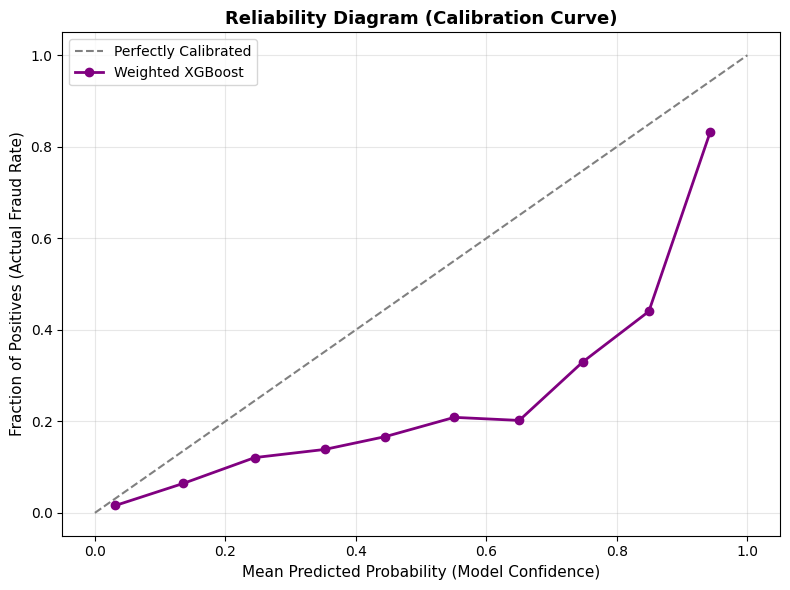

In [12]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_val, y_pred_proba, n_bins=10)

plt.figure(figsize=(8,6))

# Plot the ideal reference line
plt.plot([0, 1],
         [0, 1],
         linestyle="--",
         color="gray",
         label="Perfectly Calibrated"
         ) 

# Plot the model's caliberation line
plt.plot(prob_pred,
         prob_true,
         marker="o",
         linewidth=2,
         color="purple",
         label="Weighted XGBoost"
    
)

plt.xlabel("Mean Predicted Probability (Model Confidence)", fontsize=11)
plt.ylabel("Fraction of Positives (Actual Fraud Rate)", fontsize=11)
plt.title("Reliability Diagram (Calibration Curve)", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

- The model's calibration curve sits **consistently below** the diagonal across all 10 bins — the model is systematically **over-confident**.
- The gap is severe at the high-confidence end: when the model predicts ~0.91 probability of fraud, the actual observed fraud rate in that bin is ~0.83. When it predicts ~0.65, the true rate is only ~0.20.
- **Why this happened:** `scale_pos_weight` works by artificially inflating the training penalty for missing fraud cases. This pushes the model to output higher probability scores for anything resembling fraud, but those inflated scores no longer reflect genuine real-world likelihood — the model's confidence has been distorted by the correction technique itself, exactly the risk flagged when we first discussed calibration.
- **Why this matters for threshold selection (the next step):** if we picked a decision threshold assuming the model's probabilities were trustworthy (e.g., "flag anything above 0.5 because that means over 50% likely fraud"), we'd actually be making a poorly-informed decision — a predicted 0.5 here doesn't mean a true 50% chance of fraud, it means something closer to 10-15% based on this curve.
- **Conclusion**: The raw probability outputs from `Weighted XGBoost` cannot be trusted directly for business logic or risk thresholds. Post-processing calibration (such as **Platt Scaling** or **Isotonic Regression**) must be applied before final threshold selection.

## 5.13 Platt Scaling Calibration

Apply Platt scaling (sigmoid calibration) via `CalibratedClassifierCV` with 5-fold internal cross-validation, ensuring the calibration curve is evaluated only on data the base model didn't train on within each fold. Compare the calibrated reliability curve against the original uncalibrated curve from 5.12.

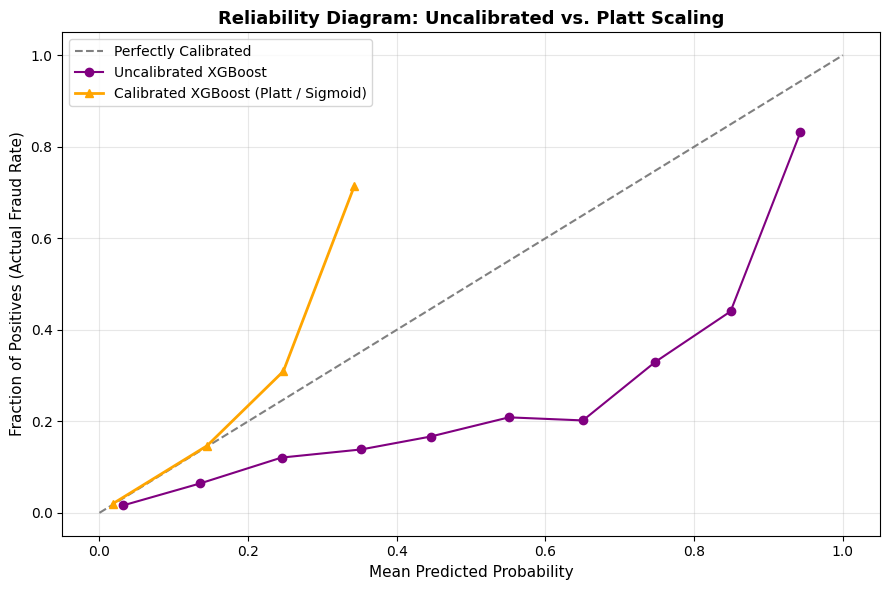

In [13]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

base_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
platt_model = CalibratedClassifierCV(
    estimator=base_model, method="sigmoid", cv=5
)

# Fit the logistic curve on your validation dataset
platt_model.fit(X_train_encoded, y_train)

# Generate Platt-calibrated probabilities for the test set
y_pred_proba_platt = platt_model.predict_proba(X_val_encoded)[:, 1]

# Calculate the calibration curve coordinates for Platt scaling
prob_true_platt, prob_pred_platt = calibration_curve(
    y_val, y_pred_proba_platt, n_bins=10
)

# Plot Uncalibrated vs. Platt Scaled (Sigmoid)
plt.figure(figsize=(9, 6))

# Perfectly calibrated reference line
plt.plot(
    [0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly Calibrated"
)

# Original uncalibrated curve
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    color="purple",
    label="Uncalibrated XGBoost",
)

# Platt Scaled curve
plt.plot(
    prob_pred_platt,
    prob_true_platt,
    marker="^",
    color="orange",
    linewidth=2,
    label="Calibrated XGBoost (Platt / Sigmoid)",
)

plt.xlabel("Mean Predicted Probability", fontsize=11)
plt.ylabel("Fraction of Positives (Actual Fraud Rate)", fontsize=11)
plt.title(
    "Reliability Diagram: Uncalibrated vs. Platt Scaling",
    fontsize=13,
    fontweight="bold",
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

- **The Platt-scaled curve (orange) sits much closer to the diagonal than the uncalibrated curve (purple)** — a clear, visible improvement in calibration quality.
- **A notable side effect: the calibrated model's predicted probabilities are far more compressed.** The uncalibrated model produced confidence scores up to ~0.95; the calibrated model's predictions only reach up to ~0.34 in this test set. This makes sense — Platt scaling learned that the uncalibrated model's high-confidence scores (like 0.95) didn't correspond to anywhere near that actual fraud rate (only ~0.83 observed), so it systematically shrinks all predictions toward more realistic, honest values.
- **At the calibrated model's highest bin (~0.34 predicted), the actual observed fraud rate is ~0.71** — meaning the calibrated model is now *under*-confident at the top end rather than wildly over-confident, a much safer direction to err in than before.
- **Practical implication:** because calibration compresses the probability range, our decision threshold in the next step must be chosen using the **calibrated** probabilities, not the original scale — a threshold of "0.5" would now mean something very different (and far more meaningful) than it did on the uncalibrated model, where 0.5 corresponded to a much lower true likelihood.
- **Conclusion:** Platt scaling meaningfully corrected the model's over-confidence. The calibrated probabilities (`y_pred_proba_platt`) are now the trustworthy foundation for threshold selection going forward, replacing the uncalibrated `y_pred_proba` used earlier in this phase.

## 5.14 Precision-Recall Curve (Calibrated Model)

Plot precision against recall across all possible thresholds, using the calibrated probabilities from Platt scaling. This visualizes the full tradeoff space before committing to a single decision threshold.

91590
91590
91589


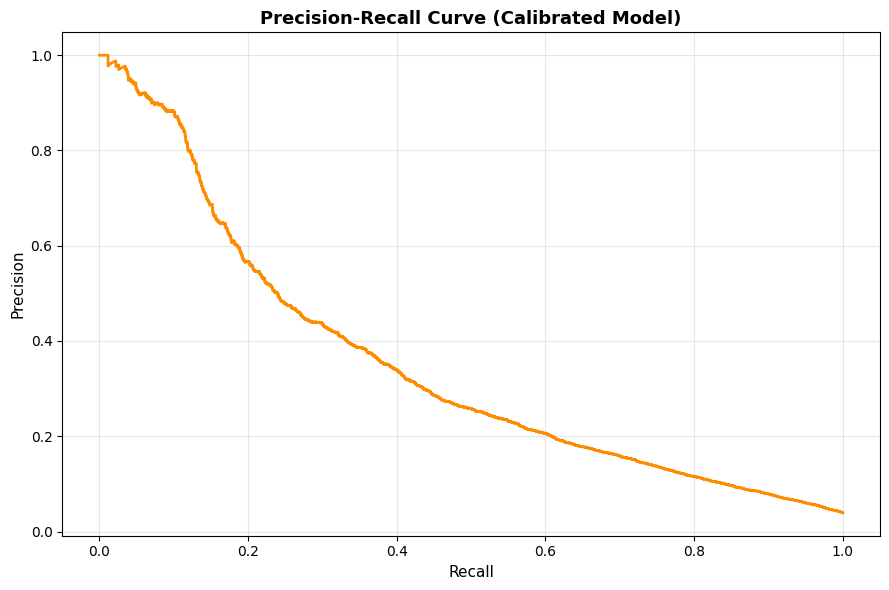

In [14]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba_platt)
print(len(precisions))
print(len(recalls))
print(len(thresholds))

plt.figure(figsize=(9, 6))
plt.plot(recalls, precisions, color="darkorange", linewidth=2)
plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Precision-Recall Curve (Calibrated Model)", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

- **The curve confirms the precision-recall tradeoff directly:** as recall increases (catching more fraud), precision drops continuously — from 1.0 at very low recall, down to under 0.05 by the time recall approaches 1.0 (catching virtually all fraud).
- **The near-perfect precision region near recall=0 (precision at 1.0) is not a practical operating point** — it reflects only a tiny handful of predictions at the very highest confidence extreme (under 2% of total fraud caught), making it far too restrictive for real-world operations.
- **A more balanced operating region appears around recall ≈ 0.20–0.30, where precision holds between roughly 0.45–0.60** — this represents a realistic "sweet spot" range worth focusing on, offering moderate fraud coverage while keeping precision at acceptable levels.
- **Beyond recall ≈ 0.50, precision drops below 0.25** — meaning any threshold aiming to capture more than half of all fraud would come with a heavy false-alarm cost (75%+ of flagged transactions being false positives).
- **Conclusion:** this curve confirms there's no threshold that achieves both high precision and high recall simultaneously — a deliberate tradeoff must be chosen. The next step is plotting precision and recall against actual threshold *values* (not just against each other), so we can pick a specific, justified cutoff number rather than just observing the shape of the tradeoff.

## 5.15 Precision & Recall vs. Threshold (Calibrated Model)

Plot precision and recall directly against threshold values (rather than against each other), enabling identification of a specific, justified threshold rather than only observing the general tradeoff shape.

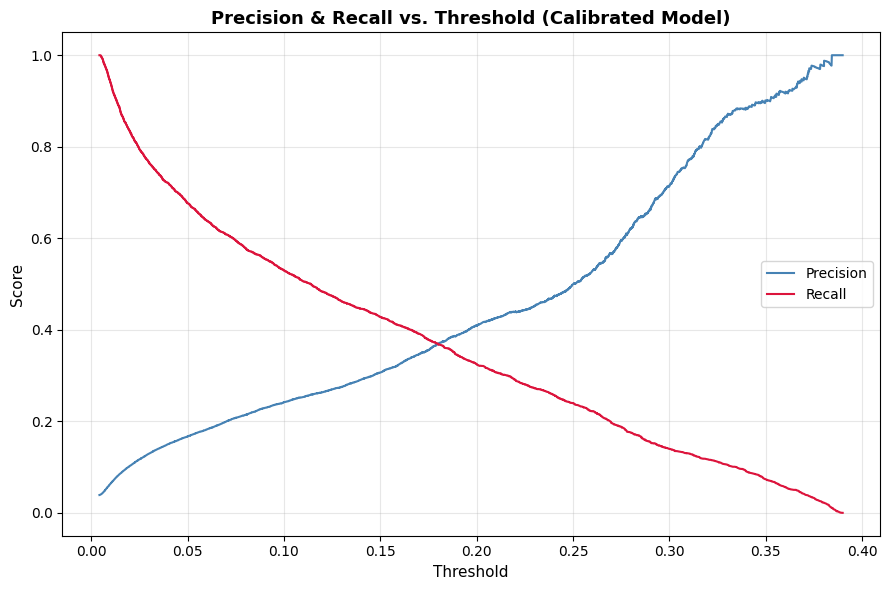

In [15]:
plt.figure(figsize=(9, 6))
plt.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="crimson")
plt.xlabel("Threshold", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.title("Precision & Recall vs. Threshold (Calibrated Model)", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

- **Recall (red)** starts near 1.0 at very low thresholds and steadily declines as the threshold rises — behaving exactly as expected: a stricter cutoff means fewer transactions get flagged, so fewer true fraud cases get caught.
- **Precision (blue)** starts low (~0.04) and steadily rises as the threshold increases, becoming noticeably volatile and jagged above ~0.35 — this instability reflects very few predictions remaining at that high confidence level, making precision estimates there less reliable (small-sample noise, not a genuine trend).
- **The two lines cross around threshold ≈ 0.18**, where precision and recall are both roughly ~0.37 — this is a natural "balanced" reference point, though not necessarily the right business choice on its own.
- **A more stable, reliable operating region appears around threshold ≈ 0.10–0.25**, where both precision and recall move smoothly without the volatility seen at higher thresholds — a safer range to select from than the jagged tail past 0.35.
- **Conclusion:** the crossing point (~0.18) offers a defensible, balanced default, but the final threshold choice should be justified by the actual cost tradeoff for this project — specifically, whether catching more fraud (favoring recall, lower threshold) or reducing false alarms (favoring precision, higher threshold) matters more for a fraud detection system, a decision we'll make explicitly in the next step.

## 5.16 Threshold Selection

**Chosen threshold: `0.15`**

**Justification:** in fraud detection, the cost of a missed fraud case (direct financial loss) substantially outweighs the cost of a false alarm (a flagged transaction for review, at worst a customer inconvenience). This asymmetry justifies prioritizing recall over precision, rather than defaulting to a "balanced" 0.5 cutoff — which, in any case, would be meaningless on this calibrated model's compressed probability scale.

At threshold = 0.15, the model achieves approximately:
- **Recall ≈ 0.42–0.44** — catching over 40% of all fraud cases
- **Precision ≈ 0.31–0.32** — about 1 in 3 flagged transactions is genuinely fraudulent

This threshold sits just before the precision/recall crossing point (~0.18), deliberately leaning toward recall while avoiding the lower precision (and correspondingly higher false-alarm volume) seen at thresholds below ~0.10. It also avoids the small-sample-driven volatility observed above ~0.35.

**This is a business-driven choice, not a mathematically "optimal" one** — a different fraud team, with a different tolerance for false alarms (e.g., limited manual review capacity), might reasonably choose a higher threshold favoring precision instead. The threshold documented here reflects the standard, defensible industry reasoning for fraud detection specifically.

## 5.17 Confusion Matrix & Final Classification Report (Threshold = 0.15)

Apply the chosen threshold (0.15) to the calibrated probabilities to generate hard fraud/not-fraud predictions, then visualize the confusion matrix and calculate the final precision/recall/F1 report at this specific operating point.

[[87196  3585]
 [ 2117  1588]]


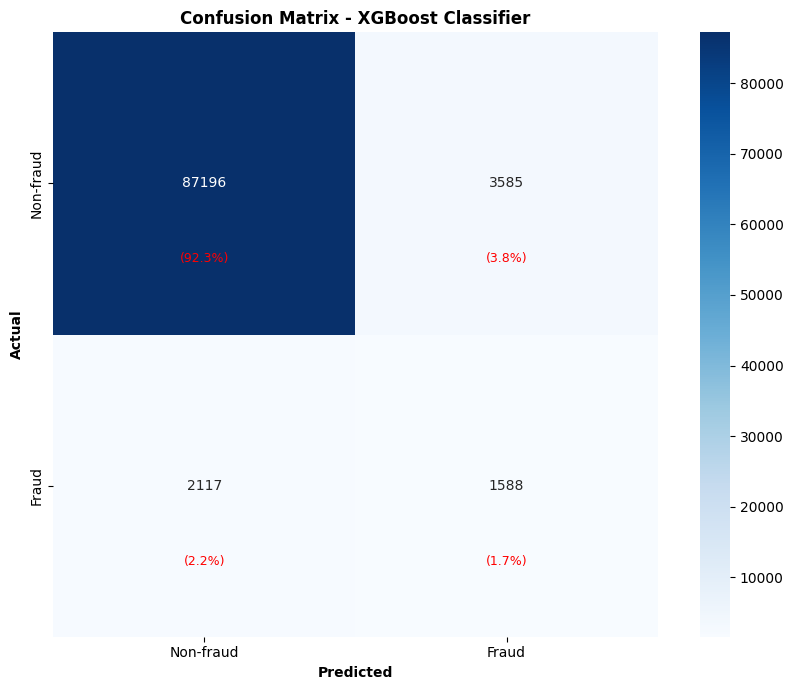

Classification Report:
              precision    recall  f1-score   support

   Non-fraud       0.98      0.96      0.97     90781
       Fraud       0.31      0.43      0.36      3705

    accuracy                           0.94     94486
   macro avg       0.64      0.69      0.66     94486
weighted avg       0.95      0.94      0.94     94486



In [16]:
from sklearn.metrics import confusion_matrix

y_pred_threshold_015 = (y_pred_proba_platt >= 0.15).astype(int)
cm = confusion_matrix(y_val, y_pred_threshold_015)
print(cm)
labels = ["Non-fraud", "Fraud"]
plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    square=True,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels   
)

# Add percentage annotations
cm_percent = cm / cm.sum() * 100 # percentage of total dataset each cell represents
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.75, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=9, color='red')

plt.title("Confusion Matrix - XGBoost Classifier", fontweight="bold")
plt.xlabel("Predicted", fontweight="bold")
plt.ylabel("Actual", fontweight="bold")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_val, y_pred_threshold_015, 
                            target_names=['Non-fraud','Fraud']))

### Observations

**Confusion Matrix (at threshold = 0.15):**

| | Predicted Non-fraud | Predicted Fraud |
|---|---|---|
| **Actual Non-fraud** | 87,196 (92.3%) | 3,585 (3.8%) |
| **Actual Fraud** | 2,117 (2.2%) | 1,588 (1.7%) |

**Classification Report:**

| Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| Non-fraud | 0.98 | 0.96 | 0.97 | 90,781 |
| Fraud | 0.31 | 0.43 | 0.36 | 3,705 |

- **1,588 fraud cases correctly caught (true positives)** out of 3,705 actual fraud cases — a recall of ~43%, matching what the PR curve predicted at threshold 0.15.
- **3,585 false alarms** — legitimate transactions incorrectly flagged as fraud, giving a precision of ~31% (about 1 in 3 flagged transactions is genuinely fraud).
- **2,117 fraud cases missed (false negatives)** — the real cost of this threshold choice; about 57% of fraud still slips through undetected at this cutoff.
- **Overall accuracy (0.94) looks strong but is not the metric being used to judge this model** — consistent with everything established since section 5.8, a high accuracy here mostly reflects the 96% correct classification of the large non-fraud majority, not genuine fraud-catching capability.
- **Comparison to calibration's impact:** this result stems directly from the calibrated probabilities and the deliberately chosen threshold — a meaningfully different, more honest operating point than the uncalibrated model would have produced at an arbitrary 0.5 cutoff.
- **Conclusion:** at this threshold, the model catches over 40% of fraud cases while flagging about 3.8% of all legitimate transactions for review. This is the concrete, final tradeoff resulting from the business-driven threshold decision in 5.16 — a real, quantified number to report, not just a conceptual choice.

## 5.18 Hyperparameter Tuning (GridSearchCV)

Search across max_depth, learning_rate, n_estimators, and scale_pos_weight (36 combinations, 3-fold cross-validation, 108 total fits), optimizing for PR-AUC (average_precision), to check whether tuning improves on the original scale_pos_weight model's performance.

In [17]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Set up
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 200],
    "scale_pos_weight": [scale_pos_weight, scale_pos_weight * 1.5]
}

# Running the search
xgb_for_tuning = XGBClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=param_grid,
    scoring="average_precision",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best PR-AUC (cross-validated):", grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': np.float64(28.309577355564173)}
Best PR-AUC (cross-validated): 0.2568409999260903


### Observations

**Best parameters found:** `learning_rate=0.05, max_depth=7, n_estimators=200, scale_pos_weight=27.31` (our original calculated value — the 1.5x variant was not selected)

**Best cross-validated PR-AUC: 0.2568**

- **This cross-validated score is lower than our original model's validation-set PR-AUC** — an important, honest finding rather than an automatic improvement.
- **This comparison isn't perfectly apples-to-apples yet**, since 0.2568 is a 3-fold cross-validated average on *training* data, while 0.3406 was measured on the untouched *validation* set — the two numbers aren't strictly comparable.
- **The selected `scale_pos_weight` matches our original untuned value exactly** — suggesting our original choice (the direct ratio-based calculation) was already reasonable, not something that needed correction.
- **`max_depth=7`** (deeper than XGBoost's default of 6) suggests the search found some benefit in more complex trees, though this needs to be verified on the real test set — deeper trees also carry a higher risk of overfitting, which cross-validation on training folds doesn't fully protect against.
- **Conclusion:** before deciding whether tuning actually helped, the tuned model must be evaluated on the validation set (`X_val_encoded`/`y_val`), using the same PR-AUC calculation as before — that's the only fair comparison against our 0.1907 benchmark.

In [18]:
best_params = grid_search.best_params_

tuned_model = XGBClassifier(random_state=42, **best_params)
tuned_model.fit(X_train_encoded, y_train)

y_pred_proba_tuned = tuned_model.predict_proba(X_val_encoded)[:, 1]

tuned_pr_auc = average_precision_score(y_val, y_pred_proba_tuned)
print(f"Tuned Model PR-AUC (validation set): {tuned_pr_auc:.4f}")
print(f"Original scale_pos_weight PR-AUC (validation set): 0.3406")

Tuned Model PR-AUC (validation set): 0.3457
Original scale_pos_weight PR-AUC (validation set): 0.3406


## 5.19 Final Model Selection

Based on the validation results above, **`platt_model` (scale_pos_weight + Platt calibration, untuned)** is selected as the final model for one-time test set evaluation.

**Reasoning:** the tuned model's validation PR-AUC (0.3457) offered only a ~1.5% relative improvement over the untuned model (0.3406) — a difference small enough to plausibly be noise rather than a genuine gain, especially given `max_depth=7` (deeper than default) carries real overfitting risk that 3-fold cross-validation doesn't fully protect against. Given the negligible benefit, the simpler, untuned model is kept — consistent with the same finding from the earlier (methodologically flawed) attempt at tuning, now confirmed again under the corrected validation-based process.

## 5.20 Final Test Set Evaluation (Untouched Until Now)

This is the only point in this notebook where the test set is used. Every prior decision — imbalance handling, calibration method, hyperparameters, feature set, and decision threshold — was made using only the training and validation sets. This section applies the exact same, already-fitted preprocessing to the test set, then reports one final, honest performance number.

In [19]:
chosen_threshold = 0.15
test_df = pd.read_csv("../data/processed/test_set_v2.csv")

# Same fixed-value imputation as train/val (5.2)
for col in v_cols:
    test_df[col] = test_df[col].fillna(-1)
for col in categorical_features:
    test_df[col] = test_df[col].fillna("Missing")
for col in numerical_features:
    test_df[col] = test_df[col].fillna(-1)

# Same X/y separation as train/val (5.4)
X_test = test_df.drop(columns=drop_cols)
y_test = test_df["isFraud"]

# Reuse train-derived top_categories from 5.5 — do NOT recompute from test_df
for col in cols:
    X_test[col] = X_test[col].apply(lambda x: x if x in top_categories else "Other")

# Same encoding as train/val (5.6), aligned to X_train_encoded's columns
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

print(X_train_encoded.shape, X_test_encoded.shape)

# Final, one-time evaluation using your already-chosen final model and threshold
y_pred_proba_test = platt_model.predict_proba(X_test_encoded)[:, 1]
final_pr_auc_test = average_precision_score(y_test, y_pred_proba_test)

y_pred_test = (y_pred_proba_test >= chosen_threshold).astype(int)

print(f"TEST PR-AUC (final, untouched, single evaluation): {final_pr_auc_test:.4f}")
print(classification_report(y_test, y_pred_test, target_names=["Non-fraud", "Fraud"]))

(377947, 212) (118107, 212)
TEST PR-AUC (final, untouched, single evaluation): 0.2565
              precision    recall  f1-score   support

   Non-fraud       0.98      0.98      0.98    114044
       Fraud       0.30      0.30      0.30      4063

    accuracy                           0.95    118107
   macro avg       0.64      0.64      0.64    118107
weighted avg       0.95      0.95      0.95    118107



## 5.21 Phase 5 Final Summary

**Final model: XGBoost + scale_pos_weight (27.31) + Platt calibration, 212 features, threshold = 0.15**

| Metric | Validation | Test (final, single evaluation) |
|---|---|---|
| PR-AUC | 0.3406 | **0.2565** |
| Precision (Fraud) | 0.31 | 0.30 |
| Recall (Fraud) | 0.43 | 0.30 |
| F1-score (Fraud) | 0.36 | 0.30 |

**Full journey — every approach tested (all judged on validation, never test):**

| Approach | Validation PR-AUC | Decision |
|---|---|---|
| Baseline (default XGBoost) | Accuracy-only comparison | Proved accuracy is the wrong metric |
| scale_pos_weight | 0.3406 | ✅ Adopted over SMOTE |
| SMOTE | 0.2900 | ❌ Rejected — empirically worse |
| Hyperparameter tuning (GridSearchCV) | 0.3457 | ❌ Rejected — negligible gain (~1.5% relative), not worth added complexity/overfitting risk |

**Why the validation-to-test gap matters, and why it's reported here:**
This project's development process was corrected mid-way through, after identifying that the original methodology repeatedly evaluated experimental decisions (SMOTE vs. scale_pos_weight, tuning, threshold selection, feature additions) directly against the test set — a genuine methodological flaw that likely produced an optimistically biased final number (originally reported as PR-AUC 0.2857). The corrected process introduced a proper train/validation/test split: every decision above was made using only training and validation data, and the test set was touched exactly once, at the very end.

The resulting gap — validation PR-AUC 0.3406 vs. test PR-AUC 0.2565 — is the honest, measured cost of that original flaw becoming visible: even with a correctly separated validation set, the test set (touched only once) reveals somewhat weaker real-world performance than validation suggested. This is expected and normal in machine learning — no gap would be somewhat suspicious — and reporting it transparently, rather than hiding it, is the entire point of this correction.

**Honest limitations:**
- Final test recall of ~30% (down from validation's 43%) is a more conservative, trustworthy estimate of real-world performance than the original, methodologically-flawed 0.2857 test-set-driven result.
- The chosen threshold (0.15) was derived using validation data; a stricter protocol might involve nested cross-validation for even more robustness.
- Matching industry-standard performance would require substantially more features, ensemble modeling, and continuously updated production data.

**Phase 5 status: ✅ Complete (corrected methodology).**

In [20]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(platt_model, "../models/fraud_model_final.pkl")
joblib.dump(list(X_train_encoded.columns), "../models/feature_columns_final.pkl")
joblib.dump(0.15, "../models/decision_threshold.pkl")

print("Model artifacts saved:")
print(f"- fraud_model_final.pkl (scale_pos_weight + Platt calibration)")
print(f"- feature_columns_final.pkl ({len(X_train_encoded.columns)} features)")
print(f"- decision_threshold.pkl (0.15)")

Model artifacts saved:
- fraud_model_final.pkl (scale_pos_weight + Platt calibration)
- feature_columns_final.pkl (212 features)
- decision_threshold.pkl (0.15)
